# Notebook Title (Heading 1)
## Major Section Heading (Heading 2)
### Subsection Heading (Heading 3)
#### Sub-subsection Heading (Heading 4)
##### Level 5 Heading
###### Level 6 Heading

# Creating a Lightcurve from a MAST Target Pixel File (TPF)
## Author
Aidan Niklaus

## Learning Goals
- Become familiar with Lightkurve basics
- Search for and download a Target Pixel File (TPF) from the Mikulski Archive for Space Telescopes (MAST)
- Create and plot a Lightcurve from a TPF using aperture masking
- Filter out background noise using aperture masking

## Keywords
TPF, Lightcurve, aperture masking

## Summary
This tutorial will demonstrate how to utilize the Python package Lightkurve to create a clean lightcurve using a TPF from the missions TESS, Kepler, or K2.

## Imports

In [49]:
import lightkurve as lk

# Makes plots appear directly after respective code block
%matplotlib inline

## Step 1: Search for and Download Target Pixel File (TPF)
In order to make any graph we need data. For the stars we will be looking at, TPFs hold this data; specifically, how much light (or flux) is emitted over time.

When we search for this data, we must tell Lightkurve for what exactly we are searching. For example, if we want to look up the star "Kepler-8" from the mission "Kepler", then we would type the following...

In [50]:
# target : the name or identifying number of your star
# mission : TESS, Kepler, or K2
search_result = lk.search_targetpixelfile(target="Kepler-8", mission="Kepler")
search_result

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,Kepler Quarter 02,2009,Kepler,60,kplr006922244,0.0
1,Kepler Quarter 02,2009,Kepler,60,kplr006922244,0.0
2,Kepler Quarter 02,2009,Kepler,60,kplr006922244,0.0
3,Kepler Quarter 03,2009,Kepler,60,kplr006922244,0.0
4,Kepler Quarter 03,2009,Kepler,60,kplr006922244,0.0
5,Kepler Quarter 03,2009,Kepler,60,kplr006922244,0.0
6,Kepler Quarter 00,2009,Kepler,1800,kplr006922244,0.0
7,Kepler Quarter 01,2009,Kepler,1800,kplr006922244,0.0
8,Kepler Quarter 02,2009,Kepler,1800,kplr006922244,0.0


That's a lot of data! If you know more information, it is often helpful to be as specific as you can as it will reduce the amount of data you and your computer have to handle.

To make it more manageable, let's only search for TPFs from quarter 2.

*Note: quarters, sectors, and campaigns are synonymous for the respective missions Kepler, TESS, and K2. They help astronomers understand where the star was being observed from when the TPF data was captured.

In [55]:
# target : the name or identifying number of your star
# mission : TESS, Kepler, or K2
# sector/quarter/campaign : from where the star was observed to make this TPF
search_result = lk.search_targetpixelfile(target="Kepler-8", mission="Kepler", quarter=2)
search_result

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,Kepler Quarter 02,2009,Kepler,60,kplr006922244,0.0
1,Kepler Quarter 02,2009,Kepler,60,kplr006922244,0.0
2,Kepler Quarter 02,2009,Kepler,60,kplr006922244,0.0
3,Kepler Quarter 02,2009,Kepler,1800,kplr006922244,0.0


Great! Now that we have a digestible search, let's download one of these TPFs from which we can make a lightcurve. Lightkurve uses normal Python indexing to catalog its searches, so if we want to download the first TPF, we must specify the 0th index.

In [56]:
tpf = search_result[0].download()

In [34]:
tpfTESS = lk.search_targetpixelfile(target="HAT-P-11", mission="TESS").download()
tpfTESS

C:\Users\aidan\anaconda3\Lib\site-packages\lightkurve\search.py:421: LightkurveWarning: Warning: 31 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


TessTargetPixelFile(TICID: 28230919)

In [44]:
tpfK2 = lk.search_targetpixelfile(target="K2-155", mission="K2")
tpfK2

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,K2 Campaign 13,2017,K2,1800,ktwo210897587,0.0


   Attribute                                                                 Description                                                              
--------------- --------------------------------------------------------------------------------------------------------------------------------------
        channel                                                                                                                                     31
         column                                                                                                                                    680
         module                                                                                                                                     10
         output                                                                                                                                      3
        quarter                                                                               

<Axes: title={'center': 'Kepler-8 Quarter 4'}, xlabel='Time - 2454833 [BKJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

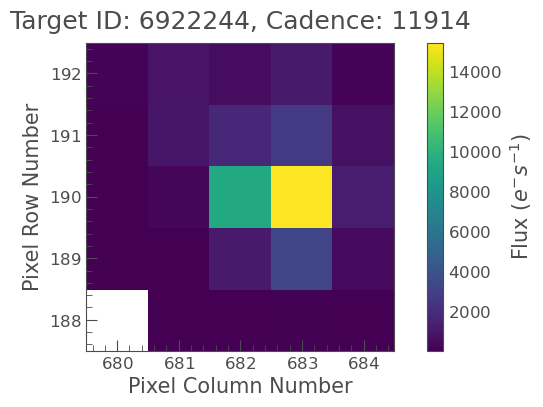

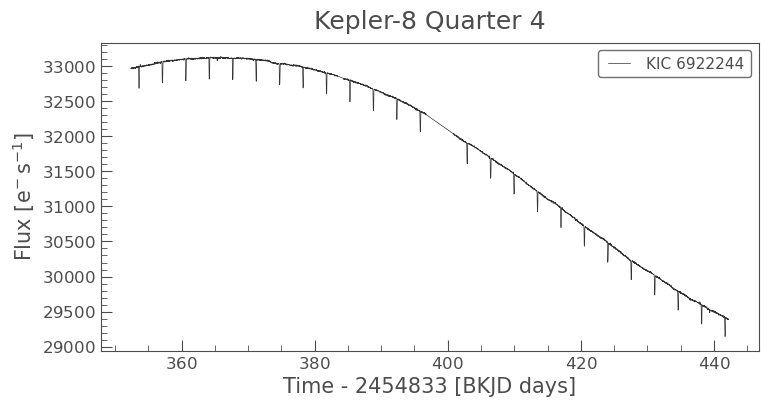

In [25]:
#TPF is a target pixel file, and can be for a variety of cadences
    #Kepler: 30 min long cadence or 1 minute short cadence
    #TESS: 30 min, 10 min, 200 sec for TPFs cut out of FFIs; 2 min, 20 sec TPFs for some pre-selected targets

#TPFs also include data about how the observation was made as well as stuff like background data, etc.

#TPFs are stores as FITS files, and Lightkurve makes it easy to work with these binary files without worrying about details of the file structure


#searching for a TPF from the Kepler mission of the star titled "Kepler-8" observed with a long cadence
    #Note: Kepler "quarters" are ~90 day observing periods, we want to work with just one of them
search_result = lk.search_targetpixelfile("Kepler-8", author="Kepler", cadence="long")

#say we want to work with the data piece (TPF) titled Quarter 4, then we gotta specify its index and download it from our overall search
tpf = search_result[4].download()

#plotting this tpf just to visually confirm what it looks like
    #we are looking at the pixels on the CCD camera, with which our star was observed. Color maps to how much flux (electrons/sec) was picked up in the pixel
tpf.plot();

#if necessary, can find out where that tpf was stored in your computer doing:
tpf.path

#furthermore, if you already had a local FITS file, instead of downloading it you can read it in:
# tpf = lk.read(<filename>)

#can access and use metadata (located in header of FITS file) of star to quickly find out/store helpful things...
tpf.get_header(ext=0)
tpf.get_header(ext=0).get('QUARTER')

#there are even some convenient shorthands for some attributes...
tpf.show_properties()
#so it becomes easier/quicker/more user friendly to write the equivalent of "tpf.get_header(ext=0).get('QUARTER')"
tpf.quarter

#the World Coordinate System (WCS) contains info about how pixel positions map to celestial sky coordinates...
type(tpf.wcs)
#so if we want sky coordinates for the bottom left corner of the tpf, we can do:
tpf.wcs.pixel_to_world(0,0)

#perhaps most important for making lightcurves are the time and flux info of the tpf:
tpf.time
tpf.flux

#TPFs are made up of a bunch of different taken datapoints (observing cadence), so time and flux data is stored as a 3D array...
    #in this example, there are 4116 images taken for flux, each of which is 5x5 pixels, altogether making up our TPF
tpf.flux.shape

#so if we want to access the observed flux of just the first 5x5 pixel image...
tpf.flux[0].value

#at each cadence the TPF has the following four flux-related data properties (all in electrons/sec):
tpf.flux   #the stellar brightness after the background is removed
tpf.flux_err   #the statistical uncertainty on the stellar flux after background removal
tpf.flux_bkg   #the astronomical background brightness of the image
tpf.flux_bkg_err   #the statistical uncertainty on the background flux

#making an aperture mask that just captures the high flux pixels (our actual star)
target_mask = tpf.create_threshold_mask(threshold=15, reference_pixel='center')
target_lc = tpf.to_lightcurve(aperture_mask=target_mask)
target_lc.plot(title="Kepler-8 Quarter " + str(tpf.quarter))   #and we get a beautiful eclipsing binary!!

#https://lightkurve.github.io/lightkurve/tutorials/1-getting-started/using-target-pixel-file-products.html